In [36]:
import pandas as pd 
from IPython.display import Image, display

data_path = "Data\\Clustering - extraindo padroes de dados\\CC GENERAL.csv"
data = pd.read_csv(data_path)
data.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


# 1. Data Treatment

In [21]:
data = pd.read_csv(data_path)
data.drop(columns=["CUST_ID", "TENURE"], inplace=True)

for item in ["CUST_ID", "TENURE"]:
    print(f"{item} - {item in data.columns}")

CUST_ID - False
TENURE - False


In [22]:
missing = data.isna().sum()
missing

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
dtype: int64

In [23]:
data.fillna(data.median(), inplace=True)
missing = data.isna().sum()
missing

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
dtype: int64

# 2. Normalização de Dados

In [24]:
from sklearn.preprocessing import Normalizer 
values = Normalizer().fit_transform(data.values)
print(values)

[[3.93555441e-02 7.87271593e-04 9.17958473e-02 ... 1.94178127e-01
  1.34239194e-01 0.00000000e+00]
 [2.93875903e-01 8.34231560e-05 0.00000000e+00 ... 3.76516684e-01
  9.84037959e-02 2.03923046e-05]
 [3.10798149e-01 1.24560965e-04 9.63068011e-02 ... 7.74852335e-02
  7.81351982e-02 0.00000000e+00]
 ...
 [2.27733092e-02 8.11060955e-04 1.40540698e-01 ... 7.90986945e-02
  8.02156174e-02 2.43318384e-04]
 [2.65257948e-02 1.64255731e-03 0.00000000e+00 ... 1.03579625e-01
  1.09898221e-01 4.92767391e-04]
 [1.86406219e-01 3.33426837e-04 5.46778061e-01 ... 3.15915455e-02
  4.41568390e-02 0.00000000e+00]]


# 3. K-Means

In [27]:
from sklearn.cluster import KMeans 
kmeans = KMeans(n_clusters=5, n_init=10, max_iter=300) #n_init - parametro que força o valor retornado ser igual. 
y_pred = kmeans.fit_predict(values)

# 4. Métricas de Validação de Clusters

* Externas - Precisamos ter os labels. Como não temos labels, usamos as métricas internas que são independentes de labels. 
* Internas - Critérios de validação: 
    * Compactação - Quão próximos estão os pontos em um mesmo cluster. 
    * Separação - Diz o quão bem separados estão os pontos em clusters distintos.


## 4.1. Coeficiente de Silhouette 
o Coeficiente de Silhouette pode variar de -1 a 1. Se o valor for maior que zero, assumimos que os clusters são válidos.

### 4.1.1. Teoria
O coeficiente de Silhouete é dado pela formula abaixo. Essa formula se baseia essencialmente nos valores de b (beta) e a (alpha): 

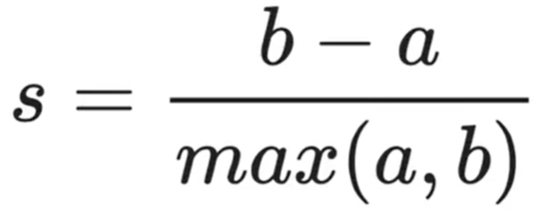

Vamos começar calculando o valor de a: 

<b> a: </b> distância média entre o ponto e todos os outros pontos do mesmo cluster.

In [32]:
from sklearn import metrics 
labels = kmeans.labels_
silhouette = metrics.silhouette_score(values, labels,metric='euclidean')
print(round(silhouette,2))

0.36


## 4.2. Davies-Boulding 


In [35]:
dbs = metrics.davies_bouldin_score(values, labels)
print(round(dbs,2))

1.08
